# **Daily Energy Consumption by Customer Segment and Season**

**Daily usage**

The daily_dataset folder contains measurements by day. We are certainly interested in:
Daily/weekly/monthly/annual usage
Usage by customer segment

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import sys
import glob


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
data_dir = "/content/gdrive/MyDrive/SMDATA/daily_dataset/"

There are 112 files in this folder, with each file containing data for 50 homes

In [ ]:
print(len(os.listdir(data_dir)))
os.listdir(data_dir)[:5]

112


['block_101.csv',
 'block_102.csv',
 'block_0.csv',
 'block_100.csv',
 'block_10.csv']

**Read data for a single home**

In [ ]:
daily_df = pd.read_csv(data_dir+'block_71.csv')
daily_df['day'] = pd.to_datetime(daily_df['day'])
daily_df = daily_df.set_index('day')
daily_df.head()

,LCLid,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
day,,,,,,,,
2011-12-07,MAC000027,0.1470,0.159880,0.408,25,0.062123,3.997,0.103
2011-12-08,MAC000027,0.1705,0.193479,0.459,48,0.077042,9.287,0.105
2011-12-09,MAC000027,0.1440,0.156771,0.365,48,0.051995,7.525,0.101
2011-12-10,MAC000027,0.2415,0.264250,0.814,48,0.135007,12.684,0.101
2011-12-11,MAC000027,0.2785,0.288438,0.540,48,0.112697,13.845,0.126


**Each home is referenced by LCLid**

In [ ]:
len(daily_df["LCLid"].unique())

50

Plot usage for a single home, noting the data mostly covers 2012-2014

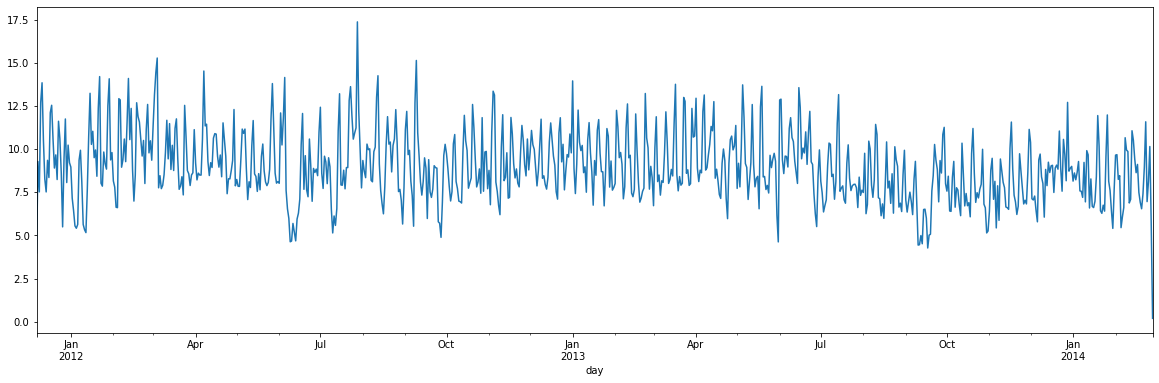

In [ ]:
daily_df[daily_df["LCLid"]=="MAC000027"]["energy_sum"].plot(figsize=(20,6), color = 'brown');

What we discover is that there is not data for all homes for all time, but it appears more homes are coming online during 2012

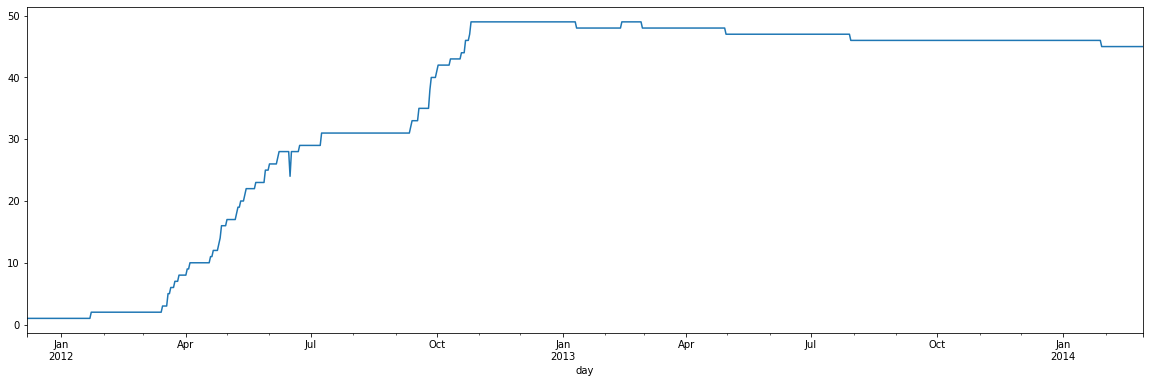

In [ ]:
daily_df.reset_index().groupby("day").nunique()["LCLid"].plot(figsize=(20,6));

In order to account for the variation in number of measurements per day, we can plot a normalised measure of energy use, energy use per household

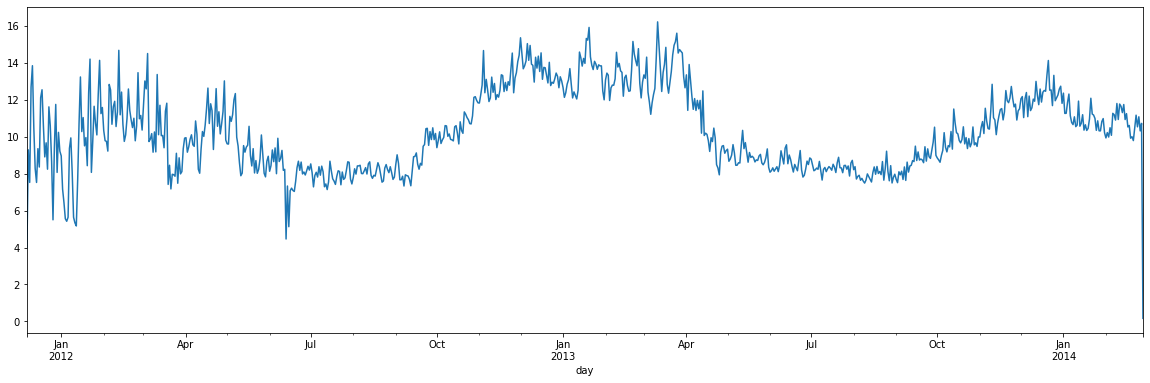

In [ ]:
num_households_df = daily_df.reset_index().groupby("day").nunique()["LCLid"] # get the number of households on each day
energy_df = daily_df.reset_index().groupby("day").sum()["energy_sum"] # get the total energy usage per day

# normalise the energy usage to the number of households and plot
energy_per_household_df = pd.concat([num_households_df, energy_df], axis=1)
energy_per_household_df["normalised"] = energy_per_household_df["energy_sum"] / energy_per_household_df["LCLid"]
energy_per_household_df["normalised"].plot(figsize=(20,6));

Trend of increased energy usage over winter months. Note the curve is more noisy in early 2012 as there are fewer homes contributing measurements.
We can get the household grouping (Acorn_grouped) from the info file, and later we will merge this with the daily energy data.

In [ ]:
info_df = pd.read_csv('/content/gdrive/MyDrive/SMDATA/informations_households.csv')
info_df.head()

,LCLid,stdorToU,Acorn,Acorn_grouped,file
0,MAC005492,ToU,ACORN-,ACORN-,block_0
1,MAC001074,ToU,ACORN-,ACORN-,block_0
2,MAC000002,Std,ACORN-A,Affluent,block_0
3,MAC003613,Std,ACORN-A,Affluent,block_0
4,MAC003597,Std,ACORN-A,Affluent,block_0


Get all data from 112 files
Merge data from all files to single df

In [ ]:
# Helper to load a single file
def daily_to_df(file_path : str) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    df['day'] = pd.to_datetime(df['day'])
    df["year"] = df["day"].apply(lambda x : x.year)
    df["month"] = df["day"].apply(lambda x : x.month)
    df["dayofweek"] = df["day"].apply(lambda x : x.dayofweek)
    df["day_name"] = df["day"].apply(lambda x : x.day_name())
    df = df.merge(info_df, on="LCLid")
    df = df[df["year"].isin([2012, 2013])]
    return df[["LCLid", "day", "year", "month", "day_name", "Acorn_grouped", "energy_sum"]]

df = daily_to_df(data_dir+'block_71.csv')
df.head()

,LCLid,day,year,month,day_name,Acorn_grouped,energy_sum
25,MAC000027,2012-01-01,2012,1,Sunday,Comfortable,8.962
26,MAC000027,2012-01-02,2012,1,Monday,Comfortable,7.159
27,MAC000027,2012-01-03,2012,1,Tuesday,Comfortable,6.430
28,MAC000027,2012-01-04,2012,1,Wednesday,Comfortable,5.556
29,MAC000027,2012-01-05,2012,1,Thursday,Comfortable,5.420


Loop over all 122 files and place in single dataframe. Note that we are just keeping data for 2012 & 2013 as these are mostly complete

In [ ]:
all_daily_df = pd.DataFrame()

for i, file_path in enumerate(glob.glob(data_dir+'*.csv')):
    all_daily_df = all_daily_df.append(daily_to_df(file_path))
    print(all_daily_df.shape)

(27417, 7)
(54134, 7)
(77135, 7)
(106327, 7)
(135469, 7)
(164422, 7)
(193616, 7)
(223639, 7)
(252784, 7)
(281359, 7)
(311752, 7)
(340264, 7)
(368600, 7)
(398848, 7)
(427993, 7)
(436972, 7)
(467897, 7)
(498445, 7)
(525659, 7)
(554167, 7)
(584431, 7)
(614396, 7)
(643865, 7)
(674232, 7)
(705296, 7)
(733828, 7)
(764058, 7)
(791209, 7)
(824265, 7)
(855542, 7)
(884930, 7)
(912500, 7)
(938567, 7)
(969459, 7)
(999195, 7)
(1032509, 7)
(1064715, 7)
(1094850, 7)
(1124064, 7)
(1153337, 7)
(1182727, 7)
(1212430, 7)
(1241648, 7)
(1270389, 7)
(1299877, 7)
(1330662, 7)
(1358687, 7)
(1387720, 7)
(1417770, 7)
(1447184, 7)
(1476330, 7)
(1505865, 7)
(1535402, 7)
(1564737, 7)
(1596989, 7)
(1627375, 7)
(1658820, 7)
(1689508, 7)
(1716411, 7)
(1745424, 7)
(1773723, 7)
(1802799, 7)
(1831728, 7)
(1862039, 7)
(1890721, 7)
(1919129, 7)
(1946333, 7)
(1973092, 7)
(1999046, 7)
(2027486, 7)
(2057209, 7)
(2084328, 7)
(2112256, 7)
(2141007, 7)
(2166718, 7)
(2192996, 7)
(2221098, 7)
(2247568, 7)
(2272111, 7)
(2297357, 7

**Additional Preprocessing**

In [ ]:
all_daily_df = all_daily_df.drop_duplicates()
all_daily_df = all_daily_df.dropna()
all_daily_df.head()

,LCLid,day,year,month,day_name,Acorn_grouped,energy_sum
37,MAC000154,2012-01-01,2012,1,Sunday,Adversity,8.773
38,MAC000154,2012-01-02,2012,1,Monday,Adversity,11.946
39,MAC000154,2012-01-03,2012,1,Tuesday,Adversity,8.045
40,MAC000154,2012-01-04,2012,1,Wednesday,Adversity,8.651
41,MAC000154,2012-01-05,2012,1,Thursday,Adversity,0.176


check that number of measurements is consistent over time, there are actually more in 2013 so we will use 2013 data in subsequent analysis

2013

In [ ]:
y2013_df = all_daily_df[all_daily_df['year']==2013]

In [ ]:
y2013_df.groupby("Acorn_grouped").count()["LCLid"]

Acorn_grouped
ACORN-            247
ACORN-U         16957
Adversity      633152
Affluent       758448
Comfortable    531420
Name: LCLid, dtype: int64

Drop the two smallest groupings

In [ ]:
y2013_df = y2013_df[y2013_df["Acorn_grouped"].isin(["Adversity", "Affluent", "Comfortable"])]

Investigate usage by group
To account for the variation in measurements over time we will just use 2013 data and we will normalise to the number of LCLid, using the normalisation approach described earlier

In [ ]:
sum_y2013_df = pd.concat([y2013_df.groupby("Acorn_grouped").sum()["energy_sum"], y2013_df.groupby("Acorn_grouped").count()["LCLid"]], axis=1)
sum_y2013_df["normalised"] = sum_y2013_df["energy_sum"] / sum_y2013_df["LCLid"]
sum_y2013_df

,energy_sum,LCLid,normalised
Acorn_grouped,,,
Adversity,5.373101e+06,633152,8.486273
Affluent,8.709586e+06,758448,11.483432
Comfortable,5.332296e+06,531420,10.034052


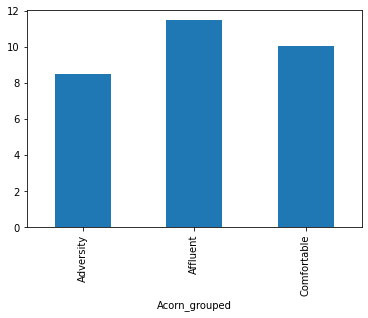

In [ ]:
sum_y2013_df["normalised"].plot.bar();

Result: Appears affluent use most energy whilst adversity the least, perhaps affluent have larger homes, more gadgets etc

**Usage by day**

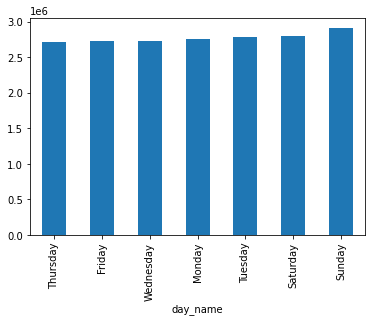

In [ ]:
y2013_df.groupby("day_name").sum()["energy_sum"].sort_values().plot.bar();

Result: Usage is slightly higher at weekends

**Usage by month (Seasonal Decomposition)**

In [ ]:
y2013_df.groupby("month").sum()["energy_sum"].sort_values().plot.bar()

Result: usage is higher over winter.

**Summary:**

This experiment emphasizes the problem of changing the number of data points over time and uses normalization to address it while also illustrating the fundamental EDA of the daily data. According to the data, Affluent homes use more energy, which is consistent with our perception. Common sense is supported by analysis of daily and seasonal trends, which show higher consumption on weekends (when people are at home) and throughout the winter.